In [1]:
#An analysis of relevant stock price responses to highly publicized events.
#Focused on the Stargate data center in Abilene, Texas, developed by Crusoe.

#Requires installation of the following, if necessary:
#pip install os yfinance numpy pandas matplotlib seaborn scipy statsmodels

Imports, setting up tickers, getting relevant stock returns:

In [16]:
#necessary imports
import os
import zipfile, io
import requests
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.api as st
from statsmodels.regression.linear_model import OLS
from datetime import datetime, timedelta

#select tickers
equipmentTickers = [
    'ETN',
    'GEV',
    'PH',
    'PWR', # new
    'VRT', # new
    'CMI' # new
]

powerTickers = [
    'VST',
    'CEG',
    'NGR', # new
    'TLN', # new
    'DUK', # new
    'NEE'  # new
]

smrTickers = [
    'SMR',
    'OKLO',
    'NNE'
]

controlTickers = [
    'SPY'
]

allTickers = equipmentTickers + powerTickers + smrTickers + controlTickers

#events
events = [
    ("2024-10-15", "Phase One build-to-suit construction announced"),
    ("2025-01-22", "White House announcement, JPMorgan $2.3B loan"),
    ("2025-03-18", "Phase Two construction (six buildings) underway"),
    ("2025-05-23", "Blue Owl and Crusoe $11.6B funding, NVIDIA GPU purchase confirmed"),
    ("2025-08-05", "Crusoe publishes inside look blog post"),
    ("2025-09-23", "First building goes live"),
    ("2025-10-14", "Ellison confirms full campus: 450,000+ GB200 GPUs, 1.2 GW"),
    ("2025-10-23", "Crusoe Series E: $1.375B raised at $10B+ valuation"),
    ("2025-11-15", "Both Phase 1 buildings operational, 200MW+"),
    ("2026-03-09", "600MW expansion canceled; winter outage revealed, Oracle denies"),
    ("2026-03-27", "Microsoft leases portion abandoned by Oracle, OpenAI. Crusoe announces Phase 3.")
]

eventsdf = pd.DataFrame(events, columns = ['date', 'eventDescription'])
eventsdf['date'] = pd.to_datetime(eventsdf['date'])
dates = eventsdf['date']

#download daily ticker prices (at close)
#begin one year before the first estimation window 
#first estimation window ends two days before first event on the list
downloadWindowStart = dates.min() - timedelta(days = 367)
downloadWindowEnd = datetime.today().strftime('%Y-%m-%d')

allPrices = yf.download(
    tickers = allTickers,
    start = downloadWindowStart,
    end = downloadWindowEnd,
    auto_adjust = True,
    progress = False
)["Close"]
allPrices.fillna(0, inplace = True)

allReturns = ((allPrices.shift(-1) / allPrices).shift(1)).tail(-1)
allLogReturns = np.log(allReturns)
allReturns.fillna(0, inplace = True)
allLogReturns.fillna(0, inplace = True)
allReturns.replace([np.inf, -np.inf], 0, inplace = True)
allLogReturns.replace([np.inf, -np.inf], 0, inplace = True)

allPricesDestination = "data/allPrices.csv"
allReturnsDestination = "data/allReturns.csv"
allLogReturnsDestination = "data/allLogReturns.csv"

allPrices.to_csv(allPricesDestination)
allReturns.to_csv(allReturnsDestination)
allLogReturns.to_csv(allLogReturnsDestination)

$NGR: possibly delisted; no price data found  (1d 2023-10-14 00:00:00 -> 2026-05-23)

1 Failed download:
['NGR']: possibly delisted; no price data found  (1d 2023-10-14 00:00:00 -> 2026-05-23)


Computing equal-weighted returns for each portfolio:

In [17]:
#compute returns for equal-weighted portfolios of each treatment category

ecolumns = []
le = len(equipmentTickers)
for etick in equipmentTickers:
    ecolumns.append(etick)
eReturns = pd.DataFrame(columns = ecolumns)
for ecol in ecolumns:
    eReturns[ecol] = allReturns[ecol]

eReturns.insert(
    loc = len(ecolumns),
    column = 'weightedReturn',
    value = 0.0
)
for etick in equipmentTickers:
    eReturns.insert(
        loc = len(ecolumns),
        column = f'{etick} weight',
        value = 0.0
    )
    
for tradingDay in eReturns.itertuples():
    enz = []
    for etick in equipmentTickers:
        zero = getattr(tradingDay, etick) == 0
        nonzero = getattr(tradingDay, etick) != 0
        if zero: eReturns.loc[tradingDay.Index, f'{etick} weight'] = 0
        if nonzero: enz.append(etick)

    for etick in enz:
        eweight = 1 / (len(enz))
        eReturns.loc[tradingDay.Index, f'{etick} weight'] = eweight
        eReturns.loc[tradingDay.Index, 'weightedReturn'] = (
            eReturns.loc[tradingDay.Index, 'weightedReturn'] +
            (eweight * eReturns.loc[tradingDay.Index, etick])
        )

eReturns.replace([np.inf, -np.inf], 0, inplace = True)
eReturnsDestination = "data/eReturns.csv"
eReturns.to_csv(eReturnsDestination)

                  
pcolumns = []
lp = len(powerTickers)
for ptick in powerTickers:
    pcolumns.append(ptick)
pReturns = pd.DataFrame(columns = pcolumns)
for pcol in pcolumns:
    pReturns[pcol] = allReturns[pcol]

pReturns.insert(
    loc = len(pcolumns),
    column = 'weightedReturn',
    value = 0.0
)
for ptick in powerTickers:
    pReturns.insert(
        loc = len(pcolumns),
        column = f'{ptick} weight',
        value = 0.0
    )
    
for tradingDay in pReturns.itertuples():
    pnz = []
    for ptick in powerTickers:
        zero = getattr(tradingDay, ptick) == 0
        nonzero = getattr(tradingDay, ptick) != 0
        if zero: pReturns.loc[tradingDay.Index, f'{ptick} weight'] = 0
        if nonzero: pnz.append(ptick)

    for ptick in pnz:
        pweight = 1 / (len(pnz))
        pReturns.loc[tradingDay.Index, f'{ptick} weight'] = pweight
        pReturns.loc[tradingDay.Index, 'weightedReturn'] = (
            pReturns.loc[tradingDay.Index, 'weightedReturn'] +
            (pweight * pReturns.loc[tradingDay.Index, ptick])
        )

pReturns.replace([np.inf, -np.inf], 0, inplace = True)
pReturnsDestination = "data/pReturns.csv"
pReturns.to_csv(pReturnsDestination)


scolumns = []
ls = len(smrTickers)
for stick in smrTickers:
    scolumns.append(stick)
sReturns = pd.DataFrame(columns = scolumns)
for scol in scolumns:
    sReturns[scol] = allReturns[scol]

sReturns.insert(
    loc = len(scolumns),
    column = 'weightedReturn',
    value = 0.0
)
for stick in smrTickers:
    sReturns.insert(
        loc = len(scolumns),
        column = f'{stick} weight',
        value = 0.0
    )
    
for tradingDay in sReturns.itertuples():
    snz = []
    for stick in smrTickers:
        zero = getattr(tradingDay, stick) == 0
        nonzero = getattr(tradingDay, stick) != 0
        if zero: sReturns.loc[tradingDay.Index, f'{stick} weight'] = 0
        if nonzero: snz.append(stick)

    for stick in snz:
        sweight = 1 / (len(snz))
        sReturns.loc[tradingDay.Index, f'{stick} weight'] = sweight
        sReturns.loc[tradingDay.Index, 'weightedReturn'] = (
            sReturns.loc[tradingDay.Index, 'weightedReturn'] +
            (sweight * sReturns.loc[tradingDay.Index, stick])
        )

sReturns.replace([np.inf, -np.inf], 0, inplace = True)
sReturnsDestination = "data/sReturns.csv"
sReturns.to_csv(sReturnsDestination)

Downloading FF3 and FF5 returns from Ken French's website

In [19]:
#incorporate Fama-French three-factor model daily returns
#originally tried with pandas_datareader
#encountered compatibility issue that way
#used requests and zipfile instead

#Fama-French five factor returns have been added as well

url3 = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"
url5 = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"

def getff(url, ffstart, ffend):
    response = requests.get(url)
    zf = zipfile.ZipFile(io.BytesIO(response.content)) 
    name = zf.namelist()[0]

    with zf.open(name) as f:
        
        #drop header rows
        #manually add encoding parameter just to be safe
        allff = pd.read_csv(f, skiprows = 4, index_col = 0, encoding = 'utf-8')
        
        #drop any remaining non-numeric rows (footer, etc)
        allff = allff[pd.to_numeric(allff['Mkt-RF'], errors = 'coerce').notna()]

        #change index column (the date) to datetime format
        allff.index = pd.to_datetime(allff.index, format = '%Y%m%d')

        #narrow it down to desired dates
        allff = allff.loc[ffstart:ffend]

        #change all factor returns (the whole dataframe) to float
        allff = allff.astype(float)

        #turn them into percentages in same format as our other returns
        allff = allff / 100
        allff = allff + 1

    return allff
    
ff3 = getff(url3, (downloadWindowStart + timedelta(days = 2)), 
            downloadWindowEnd)
ff5 = getff(url5, (downloadWindowStart + timedelta(days = 2)), 
            downloadWindowEnd)


#add index names for cleanliness
ff3.index.name = 'Date'
ff5.index.name = 'Date'
#add the daily portfolio returns 
portfolioReturns = {
    'e': eReturns,
    'p': pReturns,
    's': sReturns
}

for pname, portfolio in portfolioReturns.items():
    ff3 = pd.merge(ff3, portfolio['weightedReturn'],
        left_index = True, right_index = True, how = 'inner')
    i = len(ff3.columns)
    ff3.columns.values[i-1] = f'{pname}Weighted'

    ff5 = pd.merge(ff5, portfolio['weightedReturn'],
        left_index = True, right_index = True, how = 'inner')
    i = len(ff5.columns)
    ff5.columns.values[i-1] = f'{pname}Weighted'

In [20]:
def getEstimationWindow(eventDate):
    estimationWindowStart = eventDate - timedelta(days = 367)
    estimationWindowEnd = eventDate - timedelta(days = 2)
    estimationWindow = (estimationWindowStart, estimationWindowEnd)
    return estimationWindow
    
estimationResults3 = {}
estimationResults5 = {}

for eventDate in dates:
    window = getEstimationWindow(eventDate)
    ff3estimation = ff3.loc[window[0]:window[1]]

    ff3estimation = ff3estimation.copy()
   
    #using the columns of the ff3 dataframe, find factor betas
    ff3estimation['eExcess'] = ff3estimation['eWeighted'] - ff3estimation['RF']
    ff3estimation['pExcess'] = ff3estimation['pWeighted'] - ff3estimation['RF']
    ff3estimation['sExcess'] = ff3estimation['sWeighted'] - ff3estimation['RF']

    x3 = ff3estimation[['Mkt-RF', 'SMB', 'HML']]
    x3 = st.add_constant(x3)

    e3Model = OLS(
        ff3estimation['eExcess'],
        exog = x3, 
        missing = 'none',
        hasconst = True
    )

    p3Model = OLS(
        ff3estimation['pExcess'],
        exog = x3, 
        missing = 'none',
        hasconst = True
    )

    s3Model = OLS(
        ff3estimation['sExcess'],
        exog = x3, 
        missing = 'none',
        hasconst = True
    )

    e3Results = e3Model.fit()
    p3Results = p3Model.fit()
    s3Results = s3Model.fit()

    estimationResults3[eventDate] = {
        'equipment': e3Results,
        'power': p3Results,
        'smr': s3Results
    }


#repeat the entire process with ff5 dataframe (Fama-French five-factor)
    ff5estimation = ff5.loc[window[0]:window[1]]

    ff5estimation = ff5estimation.copy()

    ff5estimation['eExcess'] = ff5estimation['eWeighted'] - ff5estimation['RF']
    ff5estimation['pExcess'] = ff5estimation['pWeighted'] - ff5estimation['RF']
    ff5estimation['sExcess'] = ff5estimation['sWeighted'] - ff5estimation['RF']

    #print(ff5.tail())

    x5 = ff5estimation[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
    x5 = st.add_constant(x5)

    e5Model = OLS(
        ff5estimation['eExcess'],
        exog = x5, 
        missing = 'none',
        hasconst = True
    )

    p5Model = OLS(
        ff5estimation['pExcess'],
        exog = x5, 
        missing = 'none',
        hasconst = True
    )

    s5Model = OLS(
        ff5estimation['sExcess'],
        exog = x5, 
        missing = 'none',
        hasconst = True
    )

    e5Results = e5Model.fit()
    p5Results = p5Model.fit()
    s5Results = s5Model.fit()

    estimationResults5[eventDate] = {
        'equipment': e5Results,
        'power': p5Results,
        'smr': s5Results
    }

    '''print(eventDate, 'e3results:')
    print(estimationResults3[eventDate]['equipment'].summary())
    print(eventDate, 'e5Results:')
    print(estimationResults5[eventDate]['equipment'].summary())
    print(eventDate, 'p3Results:')
    print(estimationResults3[eventDate]['power'].summary())
    print(eventDate, 'p5Results:')
    print(estimationResults5[eventDate]['power'].summary())
    print(eventDate, 's3Results:')
    print(estimationResults3[eventDate]['smr'].summary())
    print(eventDate, 's5Results:')
    print(estimationResults5[eventDate]['smr'].summary())'''




In [21]:
expectedReturns3 = {}
expectedReturns5 = {}

def getExpected3(model, mkt, smb, hml):
    params = model.params
    expected3 = (
        1 +
        params['const'] +
        (params['Mkt-RF'] * mkt) +
        (params['SMB'] * smb) +
        (params['HML'] * hml)
    )

    return expected3

def getExpected5(model, mkt, smb, hml, cma, rmw):
    params = model.params
    expected5 = (
        1 +
        params['const'] +
        (params['Mkt-RF'] * mkt) +
        (params['SMB'] * smb) +
        (params['HML'] * hml) +
        (params['CMA'] * cma) +
        (params['RMW'] * rmw)
    )

    return expected5

def getEventWindow(eventDate, factorIndex, pre = 1, post = 3):
    index = factorIndex.get_indexer([eventDate], method = 'nearest')[0]
    print("calling window:", eventDate)

    eventWindowStart = index - pre
    eventWindowEnd = index + post

    return factorIndex[eventWindowStart:eventWindowEnd]
    

for eventDate in dates:

    expectedReturns3[eventDate] = {}
    expectedReturns5[eventDate] = {}
    eventWindow = getEventWindow(eventDate, ff3.index)
    
    window3Factors = ff3.loc[eventWindow]
    window5Factors = ff5.loc[eventWindow]

    for portfolio in ['equipment', 'power', 'smr']:

        model3 = estimationResults3[eventDate][portfolio]
        model5 = estimationResults5[eventDate][portfolio]

        ff3Expected = []
        ff5Expected = []

        for _, row in window3Factors.iterrows():

            expected3 = getExpected3(
                model3,
                row['Mkt-RF'],
                row['SMB'],
                row['HML']
            )
            ff3Expected.append(expected3)
            
        for _, row in window5Factors.iterrows():
            expected5 = getExpected5(
                model5,
                row['Mkt-RF'],
                row['SMB'],
                row['HML'],
                row['CMA'],
                row['RMW']
            )
            ff5Expected.append(expected5)
      
        expectedReturns3[eventDate][portfolio] = ff3Expected
        expectedReturns5[eventDate][portfolio] = ff5Expected
        print(eventDate, portfolio)
        print(ff3Expected)
        print(ff5Expected)

    


calling window: 2024-10-15 00:00:00
2024-10-15 00:00:00 equipment
[np.float64(1.0125280388488336), np.float64(0.989584204557911), np.float64(1.008574682903474), np.float64(1.0001852923749321)]
[np.float64(1.0131357464949058), np.float64(0.9888562905360767), np.float64(1.0091925552869512), np.float64(1.0005853436116332)]
2024-10-15 00:00:00 power
[np.float64(1.0096279469488951), np.float64(0.9946845332595563), np.float64(1.0061842349629446), np.float64(1.0016149434936585)]
[np.float64(1.0132634134896372), np.float64(0.9908634792266456), np.float64(1.009808623185707), np.float64(1.0023373863318785)]
2024-10-15 00:00:00 smr
[np.float64(1.0174134272907867), np.float64(1.000707644278887), np.float64(1.023518018844114), np.float64(1.0025091514594506)]
[np.float64(1.0228415022771586), np.float64(0.9979253869833186), np.float64(1.0294189688666797), np.float64(1.0009384720352248)]
calling window: 2025-01-22 00:00:00
2025-01-22 00:00:00 equipment
[np.float64(1.017447191411368), np.float64(1.0111

In [22]:
car3 = {}
car5 = {}

# for some reason the portfolio names in expectedReturns 
# are different from cols in actualff3/5
portfolio_to_column = {
    'equipment': 'eWeighted',
    'power': 'pWeighted',
    'smr': 'sWeighted'
}

# these are 615 rows, need to cut up into correct windows
actualff3 = ff3[['eWeighted', 'pWeighted', 'sWeighted']]
actualff5 = ff5[['eWeighted', 'pWeighted', 'sWeighted']]

# Store results by event
for eventDate in dates:  # Loop through events
    # Get the 4 dates for this event window
    window = getEventWindow(eventDate, actualff3.index)
    
    # Get actual returns for this window
    actual_ff3 = actualff3.loc[window]
    actual_ff5 = actualff5.loc[window] 
    
    # Store CARs for this event
    car3[eventDate] = {}
    car5[eventDate] = {}
    
    # Calculate for each portfolio
    for portfolio in ['equipment', 'power', 'smr']:

        col_name = portfolio_to_column[portfolio]
        # Get the 4 expected returns you already calculated
        expected_ff3 = expectedReturns3[eventDate][portfolio]
        expected_ff5 = expectedReturns5[eventDate][portfolio]
        
        # Get actual returns (4 values)
        actual = actual_ff3[col_name].values
        
        # Calculate abnormal returns
        abnormal_ff3 = actual / expected_ff3 - 1
        abnormal_ff5 = actual / expected_ff5 - 1
        
        # Calculate CAR (sum of abnormal returns)
        car3[eventDate][portfolio] = abnormal_ff3.sum()
        car5[eventDate][portfolio] = abnormal_ff5.sum()

# Convert to DataFrames for easy viewing
car3_df = pd.DataFrame(car3).T
car5_df = pd.DataFrame(car5).T

print("CARs - FF3 Model:")
print(car3_df.round(4))
print("\nCARs - FF5 Model:")
print(car5_df.round(4))


calling window: 2024-10-15 00:00:00
calling window: 2025-01-22 00:00:00
calling window: 2025-03-18 00:00:00
calling window: 2025-05-23 00:00:00
calling window: 2025-08-05 00:00:00
calling window: 2025-09-23 00:00:00
calling window: 2025-10-14 00:00:00
calling window: 2025-10-23 00:00:00
calling window: 2025-11-15 00:00:00
calling window: 2026-03-09 00:00:00
calling window: 2026-03-27 00:00:00
CARs - FF3 Model:
            equipment   power     smr
2024-10-15     0.0010  0.0273  0.3230
2025-01-22     0.0102  0.0264  0.3560
2025-03-18     0.0213  0.0085 -0.0088
2025-05-23     0.0053  0.0029  0.3013
2025-08-05    -0.0367 -0.0230 -0.0298
2025-09-23     0.0052  0.0058 -0.1214
2025-10-14    -0.0018  0.0168  0.0446
2025-10-23    -0.0050  0.0205 -0.0502
2025-11-15     0.0046  0.0265 -0.0934
2026-03-09     0.0242 -0.0387  0.0044
2026-03-27    -0.0409 -0.0053 -0.0495

CARs - FF5 Model:
            equipment   power     smr
2024-10-15     0.0001  0.0230  0.3139
2025-01-22     0.0096  0.0215  0.32

In [23]:
## Significance Testing (different from 0)

from scipy import stats

portfolio_to_column = {
    'equipment': 'eWeighted',
    'power': 'pWeighted',
    'smr': 'sWeighted'
}

sig_results_ff3 = {}
sig_results_ff5 = {}

L_event = 4

for eventDate in dates:
    sig_results_ff3[eventDate] = {}
    sig_results_ff5[eventDate] = {}

    for portfolio in ['equipment', 'power', 'smr']:
        # Get CARs calculated from above
        car_ff3 = car3[eventDate][portfolio]
        car_ff5 = car5[eventDate][portfolio]

        # Get model estimates
        model_ff3 = estimationResults3[eventDate][portfolio]
        model_ff5 = estimationResults5[eventDate][portfolio]

        # Get Standard deviation of residuals (sigma)
        sigma_ff3 = np.sqrt(model_ff3.scale)  # RMSE
        sigma_ff5 = np.sqrt(model_ff5.scale)

        #Compute SEs
        se_ff3 = sigma_ff3 * np.sqrt(L_event)
        se_ff5 = sigma_ff5 * np.sqrt(L_event)

        # T-stat
        t_stat_ff3 = car_ff3 / se_ff3
        t_stat_ff5 = car_ff5 / se_ff5

        #Degress freedom
        df_ff3 = model_ff3.df_resid
        df_ff5 = model_ff5.df_resid

        # P-vals
        p_value_ff3 = 2 * (1 - stats.t.cdf(abs(t_stat_ff3), df_ff3))
        p_value_ff5 = 2 * (1 - stats.t.cdf(abs(t_stat_ff5), df_ff5))

        #Store Results
        sig_results_ff3[eventDate][portfolio] = {
            'CAR': car_ff3,
            'SE': se_ff3,
            't_stat': t_stat_ff3,
            'p_value': p_value_ff3,
            'sig_05': p_value_ff3 < 0.05,
            'sig_01': p_value_ff3 < 0.01,
            'sigma': sigma_ff3,
            'df': df_ff3
        }
        
        sig_results_ff5[eventDate][portfolio] = {
            'CAR': car_ff5,
            'SE': se_ff5,
            't_stat': t_stat_ff5,
            'p_value': p_value_ff5,
            'sig_05': p_value_ff5 < 0.05,
            'sig_01': p_value_ff5 < 0.01,
            'sigma': sigma_ff5,
            'df': df_ff5
        }

    

In [24]:
## Significance testing (differnt from each other)
## We'll just use pairwise t-tests

from scipy import stats
import itertools

# Function to perform pairwise t-tests for a given event date and model
def pairwise_t_tests(car_df, event_date, model_name):
    """
    Perform pairwise t-tests between portfolios for a specific event date.
    
    Parameters:
    car_df: DataFrame with portfolios as columns and event dates as index
    event_date: The specific event date to test
    model_name: "FF3" or "FF5" for labeling
    
    Returns:
    DataFrame with pairwise comparison results
    """
    portfolios = ['equipment', 'power', 'smr']
    results = []
    
    # Get CAR values for this event date
    car_values = car_df.loc[event_date]
    
    # Perform all pairwise comparisons
    for (p1, p2) in itertools.combinations(portfolios, 2):
        # For CAR comparison, we need standard errors to compute t-statistic
        # Formula for difference in CARs: t = (CAR1 - CAR2) / sqrt(SE1^2 + SE2^2)
        
        # Get standard errors from sig_results
        if model_name == "FF3":
            se1 = sig_results_ff3[event_date][p1]['SE']
            se2 = sig_results_ff3[event_date][p2]['SE']
            df1 = sig_results_ff3[event_date][p1]['df']
            df2 = sig_results_ff3[event_date][p2]['df']
        else:  # FF5
            se1 = sig_results_ff5[event_date][p1]['SE']
            se2 = sig_results_ff5[event_date][p2]['SE']
            df1 = sig_results_ff5[event_date][p1]['df']
            df2 = sig_results_ff5[event_date][p2]['df']
        
        # Difference in CARs
        car_diff = car_values[p1] - car_values[p2]
        
        # Standard error of the difference
        se_diff = np.sqrt(se1**2 + se2**2)
        
        # T-statistic
        t_stat = car_diff / se_diff
        
        # Degrees of freedom (Satterthwaite approximation)
        df_diff = (se1**2 + se2**2)**2 / ((se1**4 / df1) + (se2**4 / df2))
        
        # P-value (two-tailed)
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df_diff))
        
        results.append({
            'Comparison': f"{p1} vs {p2}",
            'Difference': car_diff,
            'SE_Diff': se_diff,
            't_stat': t_stat,
            'df': df_diff,
            'p_value': p_value,
            'significant_05': p_value < 0.05
        })
    
    return pd.DataFrame(results)

# ============================================================
# PAIRWISE COMPARISONS FOR EACH EVENT DATE
# ============================================================
print("="*80)
print("PAIRWISE PORTFOLIO COMPARISONS BY EVENT DATE")
print("="*80)

# Store all results
pairwise_results_ff3 = {}
pairwise_results_ff5 = {}

for eventDate in dates:
    print(f"\n{'-'*60}")
    print(f"Event Date: {eventDate.date()}")
    print(f"Event Description: {eventsdf.loc[eventsdf['date'] == eventDate, 'eventDescription'].values[0]}")
    print(f"{'-'*60}")
    
    # FF3 pairwise comparisons
    print("\nFF3 Model:")
    ff3_results = pairwise_t_tests(car_ff3_df, eventDate, "FF3")
    pairwise_results_ff3[eventDate] = ff3_results
    print(ff3_results.round(4))
    
    # FF5 pairwise comparisons
    print("\nFF5 Model:")
    ff5_results = pairwise_t_tests(car_ff5_df, eventDate, "FF5")
    pairwise_results_ff5[eventDate] = ff5_results
    print(ff5_results.round(4))

# ============================================================
# SUMMARY TABLE: Significant Differences Only
# ============================================================
print("\n" + "="*80)
print("SUMMARY: Significant Differences Between Portfolios (p < 0.05)")
print("="*80)

significant_summary = []

for eventDate in dates:
    for model_name, results_dict in [("FF3", pairwise_results_ff3), ("FF5", pairwise_results_ff5)]:
        results_df = results_dict[eventDate]
        for _, row in results_df.iterrows():
            if row['significant_05']:
                significant_summary.append({
                    'Event Date': eventDate.date(),
                    'Model': model_name,
                    'Comparison': row['Comparison'],
                    'Difference': row['Difference'],
                    't_stat': row['t_stat'],
                    'p_value': row['p_value']
                })

if significant_summary:
    summary_df = pd.DataFrame(significant_summary)
    print(summary_df.round(4))
else:
    print("No significant differences between portfolios at the 5% level.")

PAIRWISE PORTFOLIO COMPARISONS BY EVENT DATE

------------------------------------------------------------
Event Date: 2024-10-15
Event Description: Phase One build-to-suit construction announced
------------------------------------------------------------

FF3 Model:
           Comparison  Difference  SE_Diff  t_stat        df  p_value  \
0  equipment vs power     -0.0055   0.0366 -0.1494  444.8932   0.8813   
1    equipment vs smr     -0.3197   0.1153 -2.7728  262.4435   0.0060   
2        power vs smr     -0.3142   0.1171 -2.6825  278.6246   0.0077   

   significant_05  
0           False  
1            True  
2            True  

FF5 Model:
           Comparison  Difference  SE_Diff  t_stat        df  p_value  \
0  equipment vs power     -0.0017   0.0363 -0.0478  444.6111   0.9619   
1    equipment vs smr     -0.3115   0.1150 -2.7093  260.4649   0.0072   
2        power vs smr     -0.3097   0.1167 -2.6540  275.6946   0.0084   

   significant_05  
0           False  
1            

In [25]:
## Create Summary Tables

# Create summary DataFrames for FF3
car_ff3_df = pd.DataFrame({date: {p: sig_results_ff3[date][p]['CAR'] for p in ['equipment', 'power', 'smr']} for date in dates}).T
se_ff3_df = pd.DataFrame({date: {p: sig_results_ff3[date][p]['SE'] for p in ['equipment', 'power', 'smr']} for date in dates}).T
tstat_ff3_df = pd.DataFrame({date: {p: sig_results_ff3[date][p]['t_stat'] for p in ['equipment', 'power', 'smr']} for date in dates}).T
pvalue_ff3_df = pd.DataFrame({date: {p: sig_results_ff3[date][p]['p_value'] for p in ['equipment', 'power', 'smr']} for date in dates}).T

# Create summary DataFrames for FF5
car_ff5_df = pd.DataFrame({date: {p: sig_results_ff5[date][p]['CAR'] for p in ['equipment', 'power', 'smr']} for date in dates}).T
se_ff5_df = pd.DataFrame({date: {p: sig_results_ff5[date][p]['SE'] for p in ['equipment', 'power', 'smr']} for date in dates}).T
tstat_ff5_df = pd.DataFrame({date: {p: sig_results_ff5[date][p]['t_stat'] for p in ['equipment', 'power', 'smr']} for date in dates}).T
pvalue_ff5_df = pd.DataFrame({date: {p: sig_results_ff5[date][p]['p_value'] for p in ['equipment', 'power', 'smr']} for date in dates}).T

# ============================================================
# FF3 MODEL RESULTS
# ============================================================
print("="*80)
print("FF3 MODEL RESULTS")
print("="*80)
print("\nCumulative Abnormal Returns (CARs):")
print(car_ff3_df.round(4))
print("\nStandard Errors:")
print(se_ff3_df.round(4))
print("\nT-Statistics:")
print(tstat_ff3_df.round(3))
print("\nP-Values:")
print(pvalue_ff3_df.round(4))
print("\nSignificant at 5% (*) and 1% (**):")
sig_stars_ff3 = pvalue_ff3_df.applymap(lambda x: '**' if x < 0.01 else ('*' if x < 0.05 else ''))
print(sig_stars_ff3)

# Summary table with stars for FF3
summary_ff3 = car_ff3_df * 100
for col in summary_ff3.columns:
    for idx in summary_ff3.index:
        star = sig_stars_ff3.loc[idx, col]
        summary_ff3.loc[idx, col] = f"{summary_ff3.loc[idx, col]:.2f}{star}"
print("\nCAR (%):")
print(summary_ff3)

# ============================================================
# FF5 MODEL RESULTS
# ============================================================
print("\n" + "="*80)
print("FF5 MODEL RESULTS")
print("="*80)
print("\nCumulative Abnormal Returns (CARs):")
print(car_ff5_df.round(4))
print("\nStandard Errors:")
print(se_ff5_df.round(4))
print("\nT-Statistics:")
print(tstat_ff5_df.round(3))
print("\nP-Values:")
print(pvalue_ff5_df.round(4))
print("\nSignificant at 5% (*) and 1% (**):")
sig_stars_ff5 = pvalue_ff5_df.applymap(lambda x: '**' if x < 0.01 else ('*' if x < 0.05 else ''))
print(sig_stars_ff5)

# Summary table with stars for FF5
summary_ff5 = car_ff5_df * 100
for col in summary_ff5.columns:
    for idx in summary_ff5.index:
        star = sig_stars_ff5.loc[idx, col]
        summary_ff5.loc[idx, col] = f"{summary_ff5.loc[idx, col]:.2f}{star}"
print("\nCAR (%):")
print(summary_ff5)

# ============================================================
# COMPARISON TABLE (FF3 vs FF5 CARs)
# ============================================================
print("\n" + "="*80)
print("COMPARISON: FF3 vs FF5 CARs")
print("="*80)

# Create side-by-side comparison
comparison = {}
for portfolio in ['equipment', 'power', 'smr']:
    comparison[portfolio] = pd.DataFrame({
        'FF3_CAR': car_ff3_df[portfolio],
        'FF5_CAR': car_ff5_df[portfolio],
        'Difference': car_ff3_df[portfolio] - car_ff5_df[portfolio]
    })
    print(f"\n{portfolio.upper()} Portfolio:")
    print(comparison[portfolio].round(4))

# ============================================================
# SUMMARY: Significant Events Only
# ============================================================
print("\n" + "="*80)
print("SUMMARY: Events with Significant Abnormal Returns (p < 0.05)")
print("="*80)

print("\nFF3 Model:")
for eventDate in dates:
    for portfolio in ['equipment', 'power', 'smr']:
        if pvalue_ff3_df.loc[eventDate, portfolio] < 0.05:
            car_pct = car_ff3_df.loc[eventDate, portfolio] * 100
            print(f"  {eventDate.date()} - {portfolio}: CAR = {car_pct:.2f}% (p = {pvalue_ff3_df.loc[eventDate, portfolio]:.4f})")

print("\nFF5 Model:")
for eventDate in dates:
    for portfolio in ['equipment', 'power', 'smr']:
        if pvalue_ff5_df.loc[eventDate, portfolio] < 0.05:
            car_pct = car_ff5_df.loc[eventDate, portfolio] * 100
            print(f"  {eventDate.date()} - {portfolio}: CAR = {car_pct:.2f}% (p = {pvalue_ff5_df.loc[eventDate, portfolio]:.4f})")


FF3 MODEL RESULTS

Cumulative Abnormal Returns (CARs):
            equipment   power     smr
2024-10-15     0.0010  0.0273  0.3230
2025-01-22     0.0102  0.0264  0.3560
2025-03-18     0.0213  0.0085 -0.0088
2025-05-23     0.0053  0.0029  0.3013
2025-08-05    -0.0367 -0.0230 -0.0298
2025-09-23     0.0052  0.0058 -0.1214
2025-10-14    -0.0018  0.0168  0.0446
2025-10-23    -0.0050  0.0205 -0.0502
2025-11-15     0.0046  0.0265 -0.0934
2026-03-09     0.0242 -0.0387  0.0044
2026-03-27    -0.0409 -0.0053 -0.0495

Standard Errors:
            equipment   power     smr
2024-10-15     0.0214  0.0297  0.1133
2025-01-22     0.0228  0.0353  0.1369
2025-03-18     0.0294  0.0386  0.1427
2025-05-23     0.0299  0.0390  0.1349
2025-08-05     0.0280  0.0382  0.1311
2025-09-23     0.0283  0.0365  0.1306
2025-10-14     0.0283  0.0355  0.1298
2025-10-23     0.0282  0.0354  0.1219
2025-11-15     0.0286  0.0345  0.1170
2026-03-09     0.0265  0.0302  0.1069
2026-03-27     0.0268  0.0312  0.1054

T-Statistics:


C:\Users\nrch0\AppData\Local\Temp\ipykernel_30408\2172364262.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sig_stars_ff3 = pvalue_ff3_df.applymap(lambda x: '**' if x < 0.01 else ('*' if x < 0.05 else ''))
C:\Users\nrch0\AppData\Local\Temp\ipykernel_30408\2172364262.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_ff3.loc[idx, col] = f"{summary_ff3.loc[idx, col]:.2f}{star}"
C:\Users\nrch0\AppData\Local\Temp\ipykernel_30408\2172364262.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.73' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_ff3.loc[idx, col] = f"{summary_ff3.loc[idx, col]:.2f}{star}"
C:\Users\nrch0\AppData\L

1.4545019620369486
1.448923299876841
0.08033547059344437
0.004019432846921467
-0.08844906228992333
-0.09676833195834883
0.21402042239082383
-0.12081616908724148


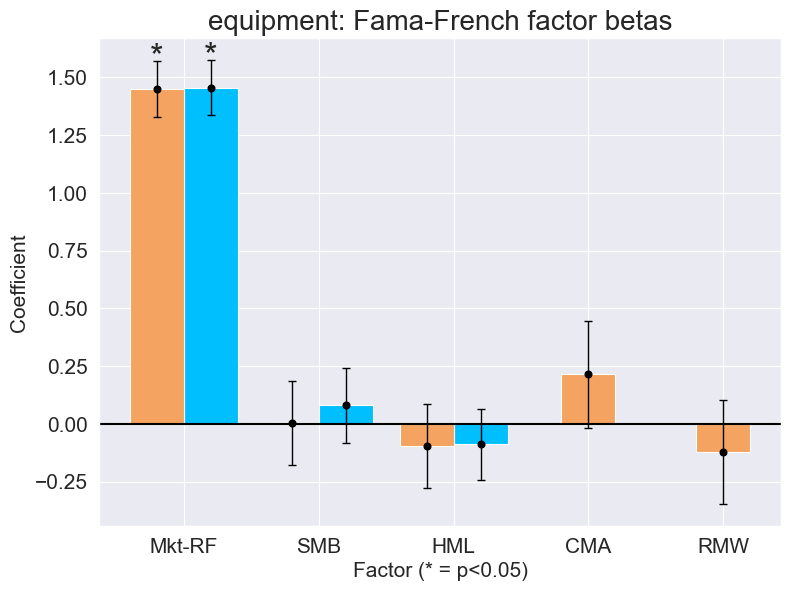

1.560249590044161
1.5448194206170196
-0.07672826604164194
-0.23973954360688485
-0.8736968717136049
-0.8503849631082107
0.5922302320188878
-0.23455245197994273


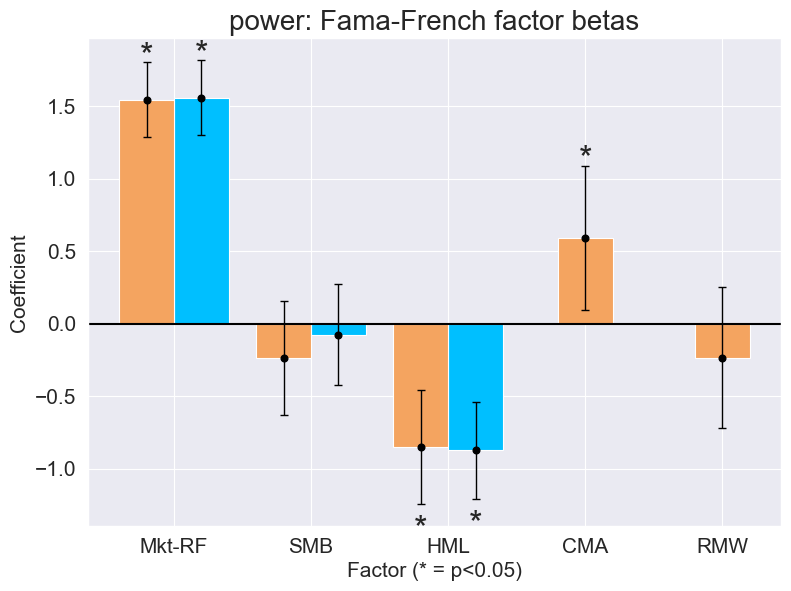

1.9138076748252542
1.5662782453784183
1.5921451566560805
0.47635930240361113
-1.4430159928469468
-1.16294927325572
0.8564559809486483
-3.0653709127333384


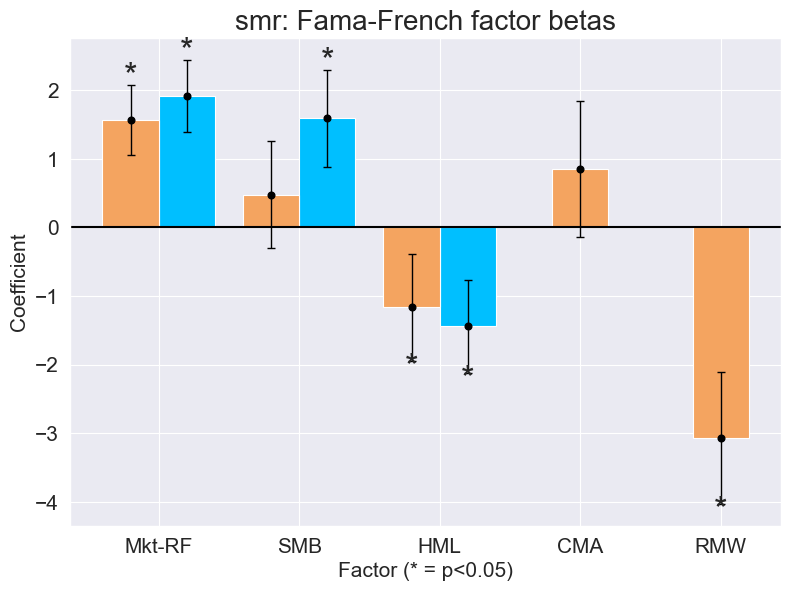

In [173]:
#extract the coefficients from OLS and create visuals
ff3factors = ['Mkt-RF', 'SMB', 'HML']
ff5factors = ['Mkt-RF', 'SMB', 'HML', 'CMA', 'RMW']
models = {
    'equipment': (e3Results, e5Results),
    'power': (p3Results, p5Results),
    'smr': (s3Results, s5Results)
}

for (modelName, (model3, model5)) in models.items():
    fig, axis = plt.subplots(figsize = (8, 6))
    
    bars = []
    barPositions = {factor: i for i, factor in enumerate(ff5factors)}
    offset = 0.2

    for factor in ff5factors:
        if factor in ff3factors:
            bars.append({
                'factor': factor,
                'model': 'ff3',
                'x': barPositions[factor] + offset,
                'width': 0.4,
                'coefficient': model3.params[factor],
                'ci_lower': model3.conf_int().loc[factor, 0],
                'ci_upper': model3.conf_int().loc[factor, 1],
                'pvalue': model3.pvalues[factor]
            })
            bars.append({
                'factor': factor,
                'model': 'ff5',
                'x': barPositions[factor] - offset,
                'width': 0.4,
                'coefficient': model5.params[factor],
                'ci_lower': model5.conf_int().loc[factor, 0],
                'ci_upper': model5.conf_int().loc[factor, 1],
                'pvalue': model5.pvalues[factor]
            })
        else: bars.append({
                'factor': factor,
                'model': 'ff5',
                'x': barPositions[factor],
                'width': 0.4,
                'coefficient': model5.params[factor],
                'ci_lower': model5.conf_int().loc[factor, 0],
                'ci_upper': model5.conf_int().loc[factor, 1],
                'pvalue': model5.pvalues[factor]
            })
    colors = {
            'ff3': 'deepskyblue',
            'ff5': 'sandybrown'
    }
    for bar in bars:
        axis.bar(x = bar['x'],
                height = bar['coefficient'],
                width = bar['width'],
                color = colors[bar['model']]
                )
        
    axis.axhline(y = 0, color = 'black', linewidth = 1.5)
    axis.set_title(f'{modelName}: Fama-French factor betas', fontsize = 20)
    axis.set_xlabel('Factor (* = p<0.05)', fontsize = 15)
    axis.set_ylabel('Coefficient', fontsize = 15)
    axis.set_xticks(range(len(ff5factors)))
    axis.set_xticklabels(ff5factors, fontsize=15)

    plt.tick_params(axis = 'x', labelsize = 15)
    plt.tick_params(axis = 'y', labelsize = 15)

    getX = {(bar['factor'], bar['model']): bar['x'] for bar in bars}
   
    for bar in bars:
        textLabels = ['ff5', 'ff3', 'ff5', 'ff3', 'ff5', 'ff3', 'ff5', 'ff5']
        xCoord = getX[(bar['factor'], bar['model'])]
        errorBarBottom = bar['coefficient'] - bar['ci_lower']
        errorBarTop = bar['ci_upper'] - bar['coefficient']
        
        axis.errorbar(
            x = xCoord,
            y = bar['coefficient'],
            yerr = [[errorBarBottom], [errorBarTop]],
            fmt = 'o',
            mfc = 'black',
            capsize = 3,
            linewidth = 1,
            barsabove = False,
            color = 'black'
        )
        
        coeffPos = bar['coefficient'] > 0
        if coeffPos:
            yCoord = bar['ci_upper'] - 0.03
        else: yCoord = bar['ci_lower'] - 0.25

        if bar['pvalue'] < 0.05:
            axis.text(
                x = xCoord,
                y = yCoord,
                s = '*',
                ha = 'center',
                fontsize=25
            )
        print(bar['coefficient'])

    plt.tight_layout()
    sb.set_theme('paper')
    plt.show()

(Timestamp('2023-10-14 00:00:00'), Timestamp('2024-10-13 00:00:00'))
            Mkt-RF     SMB     HML      RF  eWeighted  pWeighted  sWeighted  \
Date                                                                          
2023-10-17  1.0009  1.0087  1.0070  1.0002   1.007686   1.005705   0.977526   
2023-10-18  0.9854  0.9936  0.9982  1.0002   0.948298   0.993088   0.949683   
2023-10-19  0.9908  0.9950  0.9978  1.0002   0.988547   0.987551   0.941491   
2023-10-20  0.9868  1.0006  0.9985  1.0002   0.982446   0.987616   0.926980   
2023-10-23  0.9977  0.9973  0.9923  1.0002   0.995703   0.999418   0.953947   
2023-10-24  1.0074  1.0025  0.9943  1.0002   1.019403   1.022333   1.031400   
2023-10-25  0.9843  0.9969  1.0085  1.0002   0.981240   0.991422   0.976839   
2023-10-26  0.9886  1.0086  1.0167  1.0002   1.006700   1.004910   1.006199   
2023-10-27  0.9948  0.9965  0.9942  1.0002   0.991818   0.978021   0.950524   
2023-10-30  1.0115  0.9962  1.0031  1.0002   1.010842   1.0189